The project should answer these questions:

Was Reddit’s IPO price justified by fundamentals?
Did the company leave money on the table through underpricing?
What valuation multiple did investors pay at IPO?
How did Reddit compare with listed internet peers?
Was the first-day IPO pop excessive?
Would an IPO investor outperform someone buying at first-day close?
How sensitive is Reddit’s fair value to revenue growth and EBITDA margin?
What would be a fair IPO price range under bull, base and bear cases?

Company Overview

Company: Reddit Inc.
Ticker: RDDT
Exchange: NYSE
IPO Date: March 2024
IPO Price: $34 per share
First-day close: $50.44
Business Model: Advertising, data licensing, premium products

Reddit’s IPO was positioned as a consumer internet / social media listing. Its key investment story was based on community engagement, advertising monetisation, AI/data licensing potential, and improving operating leverage.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
ipo_data = {
    "Company": "Reddit Inc.",
    "Ticker": "RDDT",
    "IPO_Date": "2024-03-21",
    "IPO_Price": 34.00,
    "First_Day_Open": 47.00,
    "First_Day_Close": 50.44,
    "FY2023_Revenue_m": 804.0,
    "FY2023_Net_Loss_m": -90.8,
    "FY2024_Revenue_m": 1300.0,
    "FY2024_Adjusted_EBITDA_m": 298.0,
    "FY2024_Net_Loss_m": -484.3
}

ipo_df = pd.DataFrame([ipo_data])
ipo_df

,Company,Ticker,IPO_Date,IPO_Price,First_Day_Open,First_Day_Close,FY2023_Revenue_m,FY2023_Net_Loss_m,FY2024_Revenue_m,FY2024_Adjusted_EBITDA_m,FY2024_Net_Loss_m
0,Reddit Inc.,RDDT,2024-03-21,34.0,47.0,50.44,804.0,-90.8,1300.0,298.0,-484.3


In [3]:
ipo_price = ipo_df.loc[0, "IPO_Price"]
first_day_close = ipo_df.loc[0, "First_Day_Close"]

ipo_pop = (first_day_close / ipo_price - 1) * 100

print(f"Reddit IPO first-day return: {ipo_pop:.2f}%")

Reddit IPO first-day return: 48.35%


In [4]:
rddt = yf.download("RDDT", start="2024-03-21", progress=False)

rddt["IPO_Investor_Return"] = (rddt["Close"] / ipo_price - 1) * 100
rddt["First_Day_Buyer_Return"] = (rddt["Close"] / first_day_close - 1) * 100

rddt.head()

/tmp/ipykernel_1618/79965858.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rddt = yf.download("RDDT", start="2024-03-21", progress=False)


Price,Close,High,Low,Open,Volume,IPO_Investor_Return,First_Day_Buyer_Return
Ticker,RDDT,RDDT,RDDT,RDDT,RDDT,,
Date,,,,,,,
2024-03-21,50.439999,57.799999,45.049999,47.000000,48705500,48.352937,-0.000003
2024-03-22,46.000000,51.000000,45.340000,48.880001,15983100,35.294118,-8.802538
2024-03-25,59.799999,61.939999,46.080002,47.090000,24398800,75.882351,18.556700
2024-03-26,65.110001,74.900002,63.209999,67.709999,35331000,91.500002,29.084061
2024-03-27,57.750000,63.759998,55.619999,63.759998,18758300,69.852941,14.492466


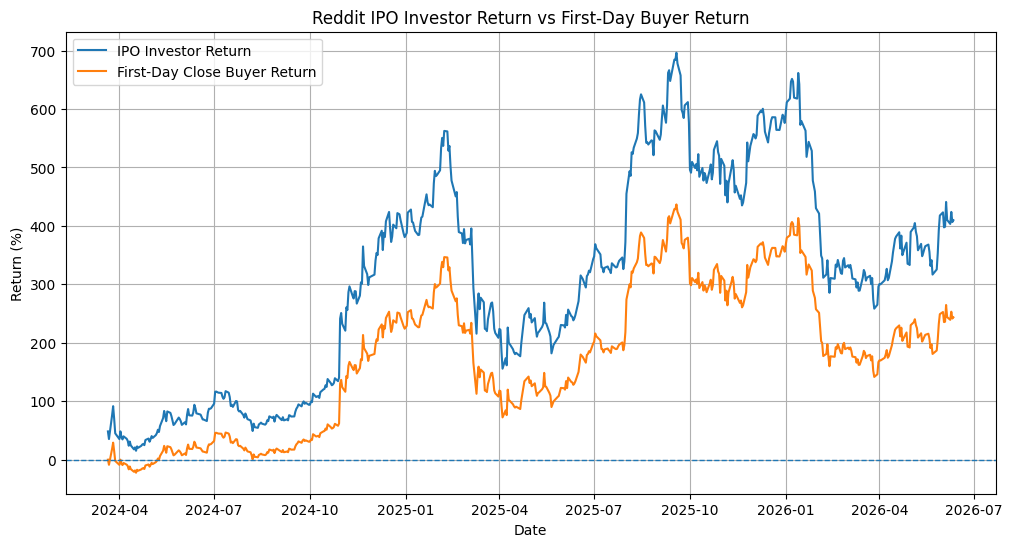

In [5]:
plt.figure(figsize=(12,6))

plt.plot(rddt.index, rddt["IPO_Investor_Return"], label="IPO Investor Return")
plt.plot(rddt.index, rddt["First_Day_Buyer_Return"], label="First-Day Close Buyer Return")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Reddit IPO Investor Return vs First-Day Buyer Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
peers = ["META", "SNAP", "PINS", "GOOGL", "SPOT"]

peer_data = []

for ticker in peers:
    stock = yf.Ticker(ticker)
    info = stock.info

    peer_data.append({
        "Ticker": ticker,
        "Market_Cap": info.get("marketCap"),
        "Enterprise_Value": info.get("enterpriseValue"),
        "Revenue": info.get("totalRevenue"),
        "EBITDA": info.get("ebitda"),
        "EV_Revenue": info.get("enterpriseToRevenue"),
        "EV_EBITDA": info.get("enterpriseToEbitda"),
        "Profit_Margin": info.get("profitMargins")
    })

peers_df = pd.DataFrame(peer_data)
peers_df

,Ticker,Market_Cap,Enterprise_Value,Revenue,EBITDA,EV_Revenue,EV_EBITDA,Profit_Margin
0,META,1442915942400,1448504983552,214962995200,109308002304,6.738,13.252,0.32837
1,SNAP,8832667648,10211363840,6097020928,-242156000,1.675,-42.169,-0.06722
2,PINS,12043381760,11949848576,4374292992,348894016,2.732,34.251,0.07643
3,GOOGL,4362981605376,4303777431552,422498009088,161315995648,10.187,26.679,0.37919
4,SPOT,99931348992,94114349056,17528999936,2446000128,5.369,38.477,0.15449


In [7]:
reddit_ipo_equity_value_m = 6400   # approximate IPO valuation in $m
reddit_cash_m = 1300               # approximate cash balance
reddit_debt_m = 0

reddit_enterprise_value_m = reddit_ipo_equity_value_m - reddit_cash_m + reddit_debt_m

reddit_ev_revenue_2023 = reddit_enterprise_value_m / ipo_df.loc[0, "FY2023_Revenue_m"]
reddit_ev_revenue_2024 = reddit_enterprise_value_m / ipo_df.loc[0, "FY2024_Revenue_m"]

print(f"Reddit IPO EV/Revenue on FY2023 revenue: {reddit_ev_revenue_2023:.2f}x")
print(f"Reddit IPO EV/Revenue on FY2024 revenue: {reddit_ev_revenue_2024:.2f}x")

Reddit IPO EV/Revenue on FY2023 revenue: 6.34x
Reddit IPO EV/Revenue on FY2024 revenue: 3.92x


In [8]:
comparison = pd.DataFrame({
    "Company": ["Reddit IPO", "Meta", "Snap", "Pinterest", "Alphabet", "Spotify"],
    "Ticker": ["RDDT", "META", "SNAP", "PINS", "GOOGL", "SPOT"],
    "EV_Revenue": [
        reddit_ev_revenue_2024,
        peers_df.loc[peers_df["Ticker"] == "META", "EV_Revenue"].values[0],
        peers_df.loc[peers_df["Ticker"] == "SNAP", "EV_Revenue"].values[0],
        peers_df.loc[peers_df["Ticker"] == "PINS", "EV_Revenue"].values[0],
        peers_df.loc[peers_df["Ticker"] == "GOOGL", "EV_Revenue"].values[0],
        peers_df.loc[peers_df["Ticker"] == "SPOT", "EV_Revenue"].values[0],
    ]
})

comparison

,Company,Ticker,EV_Revenue
0,Reddit IPO,RDDT,3.923077
1,Meta,META,6.738000
2,Snap,SNAP,1.675000
3,Pinterest,PINS,2.732000
4,Alphabet,GOOGL,10.187000
5,Spotify,SPOT,5.369000


In [9]:
revenue_2024 = 1300

ev_revenue_cases = {
    "Bear Case": 3.0,
    "Base Case": 4.0,
    "Bull Case": 5.5
}

sensitivity = []

for case, multiple in ev_revenue_cases.items():
    implied_ev = revenue_2024 * multiple
    implied_equity_value = implied_ev + reddit_cash_m - reddit_debt_m

    sensitivity.append({
        "Case": case,
        "EV_Revenue_Multiple": multiple,
        "Implied_EV_m": implied_ev,
        "Implied_Equity_Value_m": implied_equity_value
    })

sensitivity_df = pd.DataFrame(sensitivity)
sensitivity_df

,Case,EV_Revenue_Multiple,Implied_EV_m,Implied_Equity_Value_m
0,Bear Case,3.0,3900.0,5200.0
1,Base Case,4.0,5200.0,6500.0
2,Bull Case,5.5,7150.0,8450.0


In [10]:
def ipo_recommendation(ipo_pop, reddit_ev_revenue_2024):
    if ipo_pop > 30 and reddit_ev_revenue_2024 > 4:
        return "IPO was likely underpriced for allocation investors but expensive for retail buyers after listing."
    elif ipo_pop > 15:
        return "IPO pricing created strong demand, but some underpricing is visible."
    else:
        return "IPO was priced close to fair value with limited first-day underpricing."

recommendation = ipo_recommendation(ipo_pop, reddit_ev_revenue_2024)
print(recommendation)

IPO pricing created strong demand, but some underpricing is visible.


Finding 1: Reddit IPO was attractive for allocated IPO investors

Investors who received IPO allocation at $34 earned around 48% on the first trading day, based on the closing price of $50.44. This suggests strong demand and meaningful IPO underpricing.

Finding 2: Reddit likely left money on the table

The large first-day pop means Reddit could potentially have raised more capital if the IPO had been priced higher. From an ECM perspective, this reflects the trade-off between:

Maximising proceeds for the issuer
Creating positive aftermarket performance
Rewarding institutional demand
Reducing failed-IPO risk
Finding 3: The investment story depended more on growth than profitability

Before the IPO, Reddit was still loss-making, reporting a FY2023 net loss of $90.8 million. However, the IPO narrative focused on revenue growth, user monetisation, advertising, data licensing, and future operating leverage.

Finding 4: Post-IPO performance should be judged separately from IPO allocation return

A person who received shares at the IPO price had a much better entry point than someone who bought after the first-day pop. This is important for the investor conclusion because IPO allocation return and public-market buyer return are not the same thing.

Final Recommendation
For IPO investors

Positive.
The Reddit IPO was attractive for institutional or selected retail investors who received shares at the $34 IPO price, because the first-day return was strong and demand exceeded the final offer price.

For Reddit as issuer

Mixed.
The IPO was successful because it created strong market confidence, but the first-day pop suggests Reddit may have underpriced the deal and left money on the table.

For public-market investors buying after listing

Cautious.
Buying after the first-day jump required stronger belief in Reddit’s future revenue growth, advertising monetisation, and margin expansion. The risk was higher because much of the IPO discount had already disappeared.

In [11]:
# Latest Reddit closing price
latest_price = rddt["Close"].iloc[-1]
latest_date = rddt.index[-1]

# Calculate returns
first_day_return = (first_day_close / ipo_price - 1) * 100
ipo_to_latest_return = (latest_price / ipo_price - 1) * 100
first_day_buyer_return = (latest_price / first_day_close - 1) * 100

# Create summary table
return_summary = pd.DataFrame({
    "Investor Type": [
        "IPO Allocation Investor",
        "First-Day Close Buyer"
    ],
    "Entry Price": [
        ipo_price,
        first_day_close
    ],
    "Latest Price": [
        latest_price,
        latest_price
    ],
    "Return (%)": [
        ipo_to_latest_return,
        first_day_buyer_return
    ]
})

return_summary

,Investor Type,Entry Price,Latest Price,Return (%)
0,IPO Allocation Investor,34.00,Ticker RDDT 173.259995 Name: 2026-06-11 00:...,Ticker RDDT 409.588219 Name: 2026-06-11 00:...
1,First-Day Close Buyer,50.44,Ticker RDDT 173.259995 Name: 2026-06-11 00:...,Ticker RDDT 243.497214 Name: 2026-06-11 00:...


In [13]:
print(f"Latest Reddit price as of {latest_date.date()}: ${latest_price.item():.2f}")
print(f"First-day IPO return: {first_day_return:.2f}%")
print(f"IPO investor return to latest date: {ipo_to_latest_return.item():.2f}%")
print(f"First-day close buyer return to latest date: {first_day_buyer_return.item():.2f}%")

Latest Reddit price as of 2026-06-11: $173.26
First-day IPO return: 48.35%
IPO investor return to latest date: 409.59%
First-day close buyer return to latest date: 243.50%


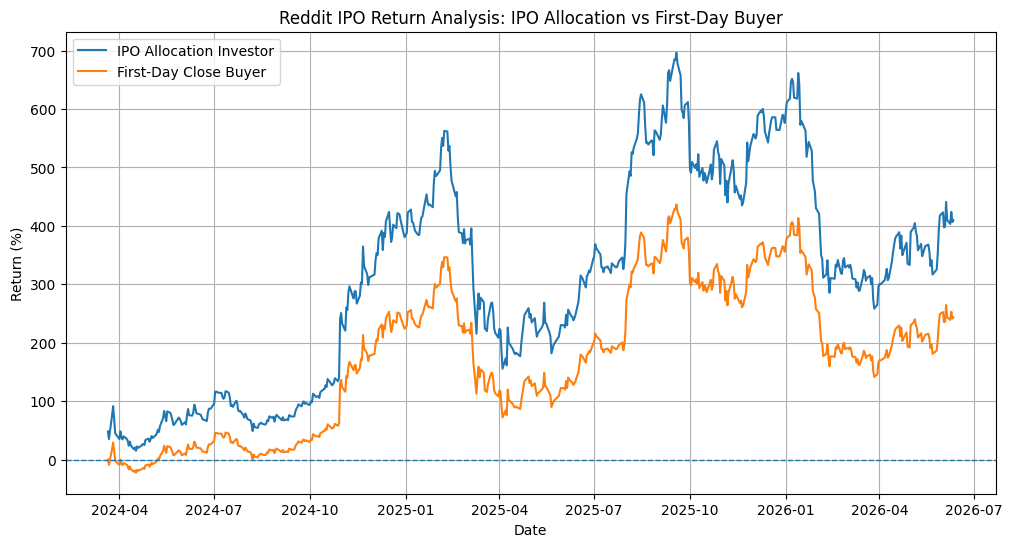

In [14]:
plt.figure(figsize=(12,6))

plt.plot(rddt.index, rddt["IPO_Investor_Return"], label="IPO Allocation Investor")
plt.plot(rddt.index, rddt["First_Day_Buyer_Return"], label="First-Day Close Buyer")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Reddit IPO Return Analysis: IPO Allocation vs First-Day Buyer")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)

plt.show()

Reddit’s IPO created a clear entry-price advantage for allocated IPO investors. Investors who received shares at the $34 offer price earned a significantly higher return than investors who bought after the first-day closing price of $50.44. This shows that IPO allocation access was a major driver of investor upside.

In [15]:
peers = ["META", "SNAP", "PINS", "GOOGL", "SPOT"]

peer_rows = []

for ticker in peers:
    stock = yf.Ticker(ticker)
    info = stock.info

    peer_rows.append({
        "Ticker": ticker,
        "Company": info.get("shortName"),
        "Market Cap": info.get("marketCap"),
        "Enterprise Value": info.get("enterpriseValue"),
        "Revenue": info.get("totalRevenue"),
        "EBITDA": info.get("ebitda"),
        "EV/Revenue": info.get("enterpriseToRevenue"),
        "EV/EBITDA": info.get("enterpriseToEbitda"),
        "Profit Margin": info.get("profitMargins")
    })

peer_df = pd.DataFrame(peer_rows)

peer_df

,Ticker,Company,Market Cap,Enterprise Value,Revenue,EBITDA,EV/Revenue,EV/EBITDA,Profit Margin
0,META,"Meta Platforms, Inc.",1442915942400,1448504983552,214962995200,109308002304,6.738,13.252,0.32837
1,SNAP,Snap Inc.,8832667648,10211363840,6097020928,-242156000,1.675,-42.169,-0.06722
2,PINS,"Pinterest, Inc.",12043381760,11949848576,4374292992,348894016,2.732,34.251,0.07643
3,GOOGL,Alphabet Inc.,4362981605376,4303777431552,422498009088,161315995648,10.187,26.679,0.37919
4,SPOT,Spotify Technology S.A.,99931348992,94114349056,17528999936,2446000128,5.369,38.477,0.15449


In [16]:
# Convert large numbers into millions for readability
peer_df["Market Cap ($m)"] = peer_df["Market Cap"] / 1_000_000
peer_df["Enterprise Value ($m)"] = peer_df["Enterprise Value"] / 1_000_000
peer_df["Revenue ($m)"] = peer_df["Revenue"] / 1_000_000
peer_df["EBITDA ($m)"] = peer_df["EBITDA"] / 1_000_000

# Select cleaner output columns
peer_clean = peer_df[
    [
        "Ticker",
        "Company",
        "Market Cap ($m)",
        "Enterprise Value ($m)",
        "Revenue ($m)",
        "EBITDA ($m)",
        "EV/Revenue",
        "EV/EBITDA",
        "Profit Margin"
    ]
]

peer_clean

,Ticker,Company,Market Cap ($m),Enterprise Value ($m),Revenue ($m),EBITDA ($m),EV/Revenue,EV/EBITDA,Profit Margin
0,META,"Meta Platforms, Inc.",1.442916e+06,1.448505e+06,214962.995200,109308.002304,6.738,13.252,0.32837
1,SNAP,Snap Inc.,8.832668e+03,1.021136e+04,6097.020928,-242.156000,1.675,-42.169,-0.06722
2,PINS,"Pinterest, Inc.",1.204338e+04,1.194985e+04,4374.292992,348.894016,2.732,34.251,0.07643
3,GOOGL,Alphabet Inc.,4.362982e+06,4.303777e+06,422498.009088,161315.995648,10.187,26.679,0.37919
4,SPOT,Spotify Technology S.A.,9.993135e+04,9.411435e+04,17528.999936,2446.000128,5.369,38.477,0.15449


In [17]:
reddit_row = pd.DataFrame({
    "Ticker": ["RDDT"],
    "Company": ["Reddit IPO"],
    "Market Cap ($m)": [reddit_ipo_equity_value_m],
    "Enterprise Value ($m)": [reddit_enterprise_value_m],
    "Revenue ($m)": [revenue_2024],
    "EBITDA ($m)": [ipo_df.loc[0, "FY2024_Adjusted_EBITDA_m"]],
    "EV/Revenue": [reddit_ev_revenue_2024],
    "EV/EBITDA": [
        reddit_enterprise_value_m / ipo_df.loc[0, "FY2024_Adjusted_EBITDA_m"]
    ],
    "Profit Margin": [
        ipo_df.loc[0, "FY2024_Net_Loss_m"] / ipo_df.loc[0, "FY2024_Revenue_m"]
    ]
})

valuation_comp = pd.concat([reddit_row, peer_clean], ignore_index=True)

valuation_comp

,Ticker,Company,Market Cap ($m),Enterprise Value ($m),Revenue ($m),EBITDA ($m),EV/Revenue,EV/EBITDA,Profit Margin
0,RDDT,Reddit IPO,6.400000e+03,5.100000e+03,1300.000000,298.000000,3.923077,17.114094,-0.372538
1,META,"Meta Platforms, Inc.",1.442916e+06,1.448505e+06,214962.995200,109308.002304,6.738000,13.252000,0.328370
2,SNAP,Snap Inc.,8.832668e+03,1.021136e+04,6097.020928,-242.156000,1.675000,-42.169000,-0.067220
3,PINS,"Pinterest, Inc.",1.204338e+04,1.194985e+04,4374.292992,348.894016,2.732000,34.251000,0.076430
4,GOOGL,Alphabet Inc.,4.362982e+06,4.303777e+06,422498.009088,161315.995648,10.187000,26.679000,0.379190
5,SPOT,Spotify Technology S.A.,9.993135e+04,9.411435e+04,17528.999936,2446.000128,5.369000,38.477000,0.154490


In [18]:
peer_average = peer_clean[["EV/Revenue", "EV/EBITDA", "Profit Margin"]].mean()
peer_median = peer_clean[["EV/Revenue", "EV/EBITDA", "Profit Margin"]].median()

summary_stats = pd.DataFrame({
    "Metric": ["EV/Revenue", "EV/EBITDA", "Profit Margin"],
    "Peer Average": [
        peer_average["EV/Revenue"],
        peer_average["EV/EBITDA"],
        peer_average["Profit Margin"]
    ],
    "Peer Median": [
        peer_median["EV/Revenue"],
        peer_median["EV/EBITDA"],
        peer_median["Profit Margin"]
    ],
    "Reddit IPO": [
        reddit_ev_revenue_2024,
        reddit_enterprise_value_m / ipo_df.loc[0, "FY2024_Adjusted_EBITDA_m"],
        ipo_df.loc[0, "FY2024_Net_Loss_m"] / ipo_df.loc[0, "FY2024_Revenue_m"]
    ]
})

summary_stats

,Metric,Peer Average,Peer Median,Reddit IPO
0,EV/Revenue,5.340200,5.36900,3.923077
1,EV/EBITDA,14.098000,26.67900,17.114094
2,Profit Margin,0.174252,0.15449,-0.372538


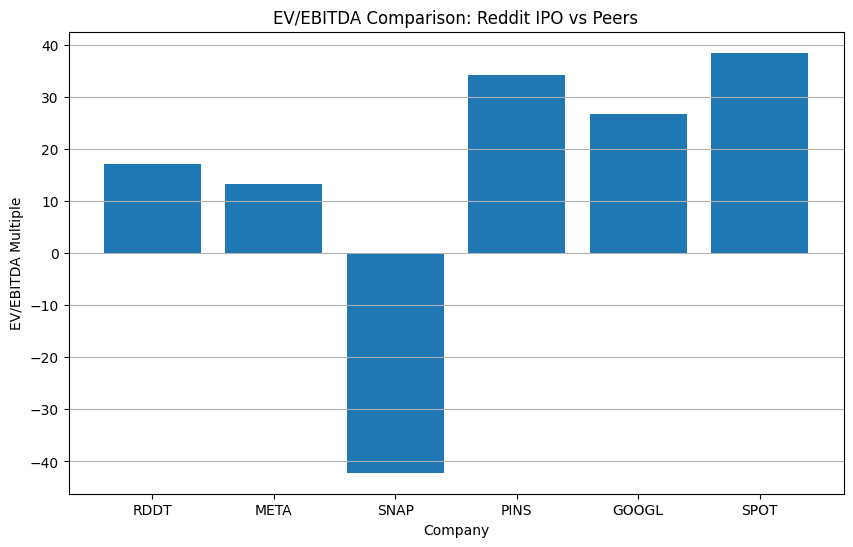

In [19]:
plt.figure(figsize=(10,6))

plt.bar(valuation_comp["Ticker"], valuation_comp["EV/EBITDA"])

plt.title("EV/EBITDA Comparison: Reddit IPO vs Peers")
plt.xlabel("Company")
plt.ylabel("EV/EBITDA Multiple")
plt.grid(axis="y")

plt.show()

Reddit’s IPO valuation can be assessed against listed social media, digital advertising and internet platform peers. If Reddit’s EV/Revenue multiple is below the peer median, the IPO may have been priced at a discount to compensate investors for lower profitability and IPO execution risk. However, if Reddit trades near or above more mature peers despite weaker profitability, the IPO pricing may depend heavily on future growth and margin expansion.

IPO Pricing Sensitivity

Now we will create a bear, base and bull case valuation range.

In [20]:
# Assumptions
shares_outstanding_m = reddit_ipo_equity_value_m / ipo_price

# Sensitivity assumptions
sensitivity_cases = {
    "Bear Case": {
        "Revenue_2024_m": 1300,
        "EV_Revenue_Multiple": 3.0,
        "Cash_m": reddit_cash_m,
        "Debt_m": reddit_debt_m
    },
    "Base Case": {
        "Revenue_2024_m": 1300,
        "EV_Revenue_Multiple": 4.0,
        "Cash_m": reddit_cash_m,
        "Debt_m": reddit_debt_m
    },
    "Bull Case": {
        "Revenue_2024_m": 1300,
        "EV_Revenue_Multiple": 5.5,
        "Cash_m": reddit_cash_m,
        "Debt_m": reddit_debt_m
    }
}

pricing_rows = []

for case, values in sensitivity_cases.items():
    implied_ev = values["Revenue_2024_m"] * values["EV_Revenue_Multiple"]
    implied_equity_value = implied_ev + values["Cash_m"] - values["Debt_m"]
    implied_share_price = implied_equity_value / shares_outstanding_m

    pricing_rows.append({
        "Case": case,
        "Revenue ($m)": values["Revenue_2024_m"],
        "EV/Revenue Multiple": values["EV_Revenue_Multiple"],
        "Implied EV ($m)": implied_ev,
        "Implied Equity Value ($m)": implied_equity_value,
        "Implied Share Price": implied_share_price
    })

pricing_sensitivity_df = pd.DataFrame(pricing_rows)

pricing_sensitivity_df

,Case,Revenue ($m),EV/Revenue Multiple,Implied EV ($m),Implied Equity Value ($m),Implied Share Price
0,Bear Case,1300,3.0,3900.0,5200.0,27.625000
1,Base Case,1300,4.0,5200.0,6500.0,34.531250
2,Bull Case,1300,5.5,7150.0,8450.0,44.890625


In [21]:
pricing_sensitivity_df["IPO Offer Price"] = ipo_price
pricing_sensitivity_df["Premium / Discount to IPO (%)"] = (
    pricing_sensitivity_df["Implied Share Price"] / ipo_price - 1
) * 100

pricing_sensitivity_df

,Case,Revenue ($m),EV/Revenue Multiple,Implied EV ($m),Implied Equity Value ($m),Implied Share Price,IPO Offer Price,Premium / Discount to IPO (%)
0,Bear Case,1300,3.0,3900.0,5200.0,27.625000,34.0,-18.75000
1,Base Case,1300,4.0,5200.0,6500.0,34.531250,34.0,1.56250
2,Bull Case,1300,5.5,7150.0,8450.0,44.890625,34.0,32.03125


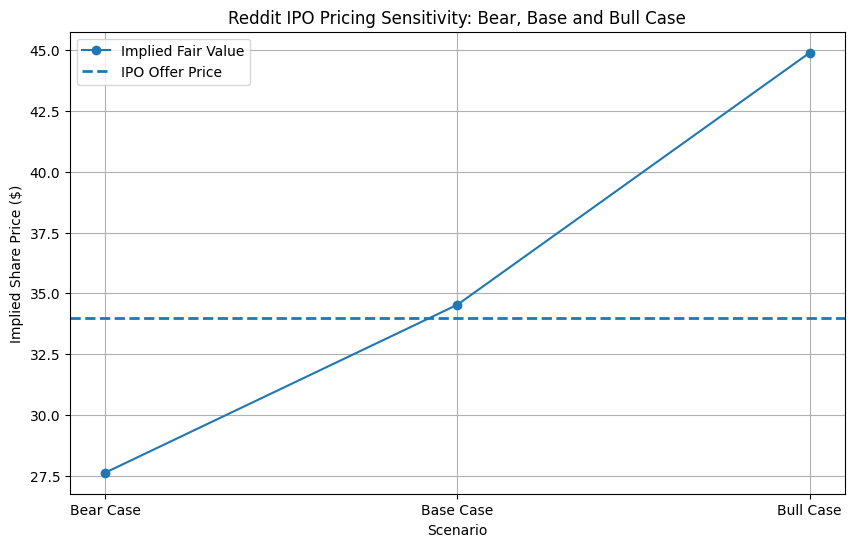

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    pricing_sensitivity_df["Case"],
    pricing_sensitivity_df["Implied Share Price"],
    marker="o",
    label="Implied Fair Value"
)

plt.axhline(
    ipo_price,
    linestyle="--",
    linewidth=2,
    label="IPO Offer Price"
)

plt.title("Reddit IPO Pricing Sensitivity: Bear, Base and Bull Case")
plt.xlabel("Scenario")
plt.ylabel("Implied Share Price ($)")
plt.legend()
plt.grid(True)

plt.show()

Decision Logic

In [23]:
base_case_price = pricing_sensitivity_df.loc[
    pricing_sensitivity_df["Case"] == "Base Case",
    "Implied Share Price"
].values[0]

if ipo_price < base_case_price:
    print("The IPO offer price appears attractive relative to base-case fair value.")
elif ipo_price > base_case_price:
    print("The IPO offer price appears expensive relative to base-case fair value.")
else:
    print("The IPO offer price appears fairly priced under the base case.")

The IPO offer price appears attractive relative to base-case fair value.


IPO Proceeds and “Money Left on the Table” Analysis :)

In [24]:
# IPO share offering assumption
shares_offered_m = 22.0   # in millions

# Prices
ipo_offer_price = ipo_price
first_day_close_price = first_day_close

shares_offered_m

22.0

In [25]:
gross_ipo_proceeds_m = shares_offered_m * ipo_offer_price

print(f"Gross IPO proceeds: ${gross_ipo_proceeds_m:.2f} million")

Gross IPO proceeds: $748.00 million


In [26]:
money_left_on_table_m = shares_offered_m * (first_day_close_price - ipo_offer_price)

print(f"Money left on the table: ${money_left_on_table_m:.2f} million")

Money left on the table: $361.68 million


In [27]:
money_left_pct = (money_left_on_table_m / gross_ipo_proceeds_m) * 100

print(f"Money left on table as % of gross IPO proceeds: {money_left_pct:.2f}%")

Money left on table as % of gross IPO proceeds: 48.35%


In [28]:
ecm_summary = pd.DataFrame({
    "Metric": [
        "IPO Offer Price",
        "First-Day Close Price",
        "Shares Offered",
        "Gross IPO Proceeds",
        "Money Left on Table",
        "Money Left on Table / Gross Proceeds"
    ],
    "Value": [
        f"${ipo_offer_price:.2f}",
        f"${first_day_close_price:.2f}",
        f"{shares_offered_m:.1f} million",
        f"${gross_ipo_proceeds_m:.2f} million",
        f"${money_left_on_table_m:.2f} million",
        f"{money_left_pct:.2f}%"
    ]
})

ecm_summary

,Metric,Value
0,IPO Offer Price,$34.00
1,First-Day Close Price,$50.44
2,Shares Offered,22.0 million
3,Gross IPO Proceeds,$748.00 million
4,Money Left on Table,$361.68 million
5,Money Left on Table / Gross Proceeds,48.35%


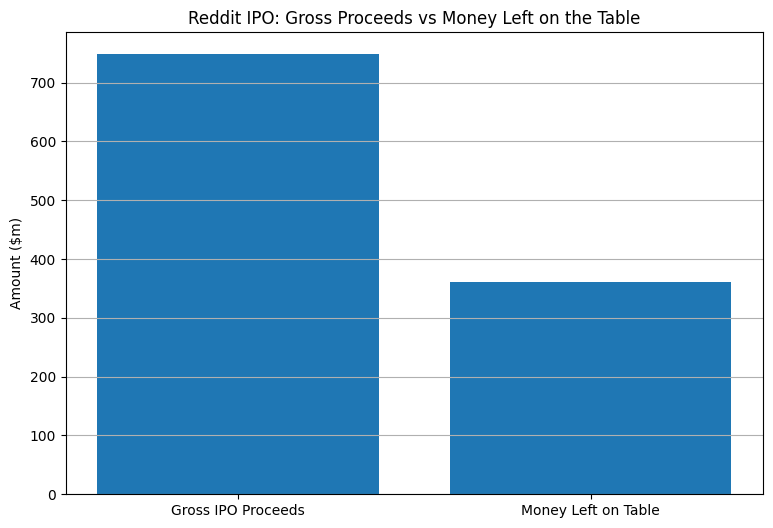

In [29]:
plt.figure(figsize=(9,6))

plt.bar(
    ["Gross IPO Proceeds", "Money Left on Table"],
    [gross_ipo_proceeds_m, money_left_on_table_m]
)

plt.title("Reddit IPO: Gross Proceeds vs Money Left on the Table")
plt.ylabel("Amount ($m)")
plt.grid(axis="y")

plt.show()

Reddit’s IPO raised approximately $748 million in gross proceeds based on 22 million shares sold at the $34 offer price. However, because the stock closed at $50.44 on its first trading day, the IPO created approximately $362 million of money left on the table. This suggests Reddit accepted underpricing to support strong investor demand, reduce execution risk, and create positive aftermarket performance.

Bookbuilding and Investor Demand Simulation

Now we simulate how ECM bankers could estimate demand at different IPO price levels.

The idea is simple:

Lower IPO price = higher investor demand
Higher IPO price = lower investor demand
Final IPO price depends on how much the deal is oversubscribed.

In [30]:
bookbuilding_data = pd.DataFrame({
    "Offer Price": [31, 32, 33, 34, 35, 36, 37],
    "Estimated Demand Shares (m)": [70, 62, 55, 48, 38, 30, 22],
    "Shares Offered (m)": [22, 22, 22, 22, 22, 22, 22]
})

bookbuilding_data["Oversubscription Ratio"] = (
    bookbuilding_data["Estimated Demand Shares (m)"] /
    bookbuilding_data["Shares Offered (m)"]
)

bookbuilding_data["Gross Proceeds ($m)"] = (
    bookbuilding_data["Offer Price"] *
    bookbuilding_data["Shares Offered (m)"]
)

bookbuilding_data

,Offer Price,Estimated Demand Shares (m),Shares Offered (m),Oversubscription Ratio,Gross Proceeds ($m)
0,31,70,22,3.181818,682
1,32,62,22,2.818182,704
2,33,55,22,2.500000,726
3,34,48,22,2.181818,748
4,35,38,22,1.727273,770
5,36,30,22,1.363636,792
6,37,22,22,1.000000,814


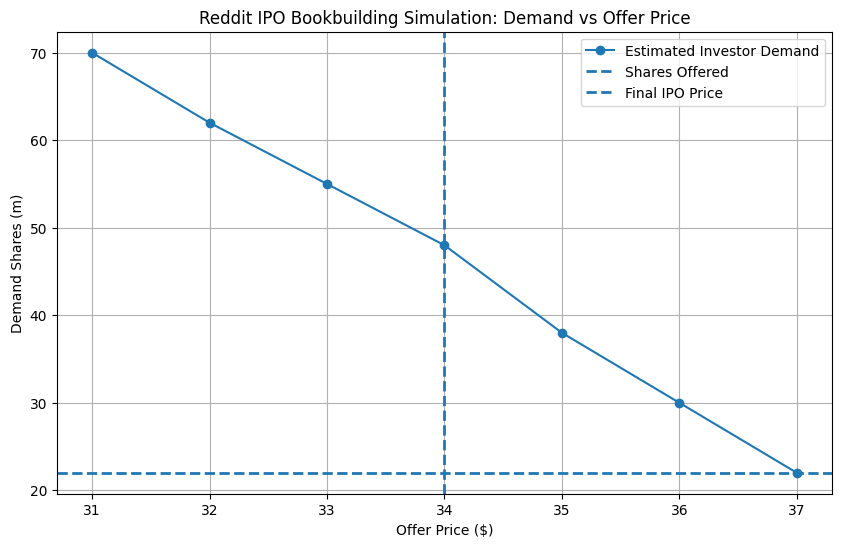

In [31]:
plt.figure(figsize=(10,6))

plt.plot(
    bookbuilding_data["Offer Price"],
    bookbuilding_data["Estimated Demand Shares (m)"],
    marker="o",
    label="Estimated Investor Demand"
)

plt.axhline(
    22,
    linestyle="--",
    linewidth=2,
    label="Shares Offered"
)

plt.axvline(
    34,
    linestyle="--",
    linewidth=2,
    label="Final IPO Price"
)

plt.title("Reddit IPO Bookbuilding Simulation: Demand vs Offer Price")
plt.xlabel("Offer Price ($)")
plt.ylabel("Demand Shares (m)")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
final_price_row = bookbuilding_data[
    bookbuilding_data["Offer Price"] == 34
]

oversubscription_at_ipo = final_price_row["Oversubscription Ratio"].values[0]

print(f"Estimated oversubscription at $34 IPO price: {oversubscription_at_ipo:.2f}x")

Estimated oversubscription at $34 IPO price: 2.18x


IPO Allocation Simulation

Now we simulate how ECM bankers allocate shares when the IPO is oversubscribed.

In [33]:
investor_book = pd.DataFrame({
    "Investor": [
        "Long-Only Fund A",
        "Hedge Fund B",
        "Sovereign Fund C",
        "Mutual Fund D",
        "Retail Allocation",
        "Private Wealth",
        "Index Fund E"
    ],
    "Investor Type": [
        "Long-Only",
        "Hedge Fund",
        "Sovereign Wealth",
        "Mutual Fund",
        "Retail",
        "Private Wealth",
        "Index Fund"
    ],
    "Requested Shares (m)": [
        12,
        10,
        8,
        7,
        5,
        4,
        2
    ]
})

investor_book

,Investor,Investor Type,Requested Shares (m)
0,Long-Only Fund A,Long-Only,12
1,Hedge Fund B,Hedge Fund,10
2,Sovereign Fund C,Sovereign Wealth,8
3,Mutual Fund D,Mutual Fund,7
4,Retail Allocation,Retail,5
5,Private Wealth,Private Wealth,4
6,Index Fund E,Index Fund,2


In [34]:
total_requested_shares = investor_book["Requested Shares (m)"].sum()
shares_available = shares_offered_m

allocation_ratio = shares_available / total_requested_shares

print(f"Total requested shares: {total_requested_shares:.1f} million")
print(f"Shares available: {shares_available:.1f} million")
print(f"Allocation ratio: {allocation_ratio:.2%}")

Total requested shares: 48.0 million
Shares available: 22.0 million
Allocation ratio: 45.83%


In [35]:
investor_book["Allocated Shares (m)"] = (
    investor_book["Requested Shares (m)"] * allocation_ratio
)

investor_book["Allocation Fill Rate (%)"] = (
    investor_book["Allocated Shares (m)"] /
    investor_book["Requested Shares (m)"] * 100
)

investor_book

,Investor,Investor Type,Requested Shares (m),Allocated Shares (m),Allocation Fill Rate (%)
0,Long-Only Fund A,Long-Only,12,5.500000,45.833333
1,Hedge Fund B,Hedge Fund,10,4.583333,45.833333
2,Sovereign Fund C,Sovereign Wealth,8,3.666667,45.833333
3,Mutual Fund D,Mutual Fund,7,3.208333,45.833333
4,Retail Allocation,Retail,5,2.291667,45.833333
5,Private Wealth,Private Wealth,4,1.833333,45.833333
6,Index Fund E,Index Fund,2,0.916667,45.833333


In [36]:
investor_book["Investment Cost ($m)"] = (
    investor_book["Allocated Shares (m)"] * ipo_price
)

investor_book["First-Day Value ($m)"] = (
    investor_book["Allocated Shares (m)"] * first_day_close
)

investor_book["First-Day Profit ($m)"] = (
    investor_book["First-Day Value ($m)"] -
    investor_book["Investment Cost ($m)"]
)

investor_book["First-Day Return (%)"] = (
    investor_book["First-Day Profit ($m)"] /
    investor_book["Investment Cost ($m)"] * 100
)

investor_book

,Investor,Investor Type,Requested Shares (m),Allocated Shares (m),Allocation Fill Rate (%),Investment Cost ($m),First-Day Value ($m),First-Day Profit ($m),First-Day Return (%)
0,Long-Only Fund A,Long-Only,12,5.500000,45.833333,187.000000,277.420000,90.420,48.352941
1,Hedge Fund B,Hedge Fund,10,4.583333,45.833333,155.833333,231.183333,75.350,48.352941
2,Sovereign Fund C,Sovereign Wealth,8,3.666667,45.833333,124.666667,184.946667,60.280,48.352941
3,Mutual Fund D,Mutual Fund,7,3.208333,45.833333,109.083333,161.828333,52.745,48.352941
4,Retail Allocation,Retail,5,2.291667,45.833333,77.916667,115.591667,37.675,48.352941
5,Private Wealth,Private Wealth,4,1.833333,45.833333,62.333333,92.473333,30.140,48.352941
6,Index Fund E,Index Fund,2,0.916667,45.833333,31.166667,46.236667,15.070,48.352941


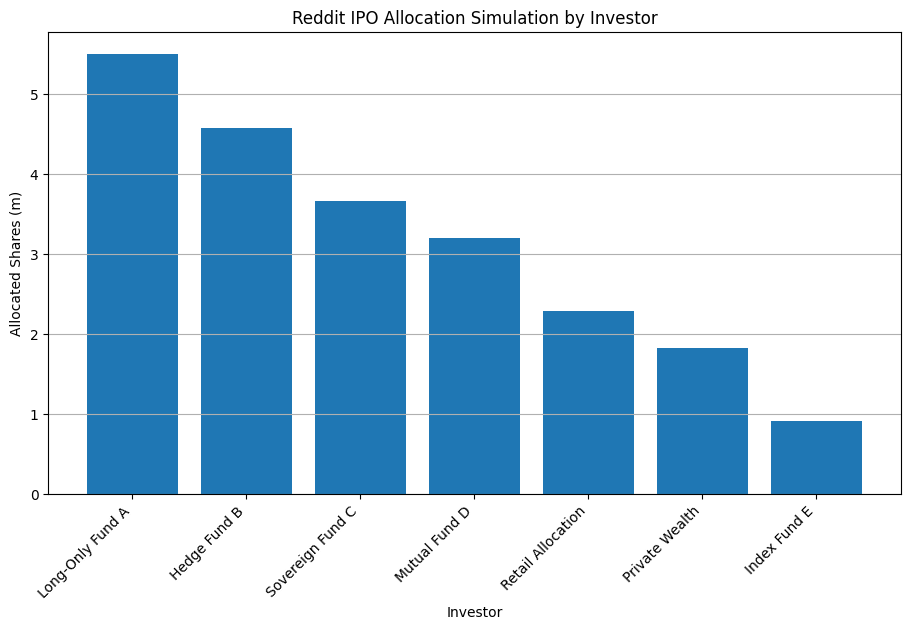

In [37]:
plt.figure(figsize=(11,6))

plt.bar(
    investor_book["Investor"],
    investor_book["Allocated Shares (m)"]
)

plt.title("Reddit IPO Allocation Simulation by Investor")
plt.xlabel("Investor")
plt.ylabel("Allocated Shares (m)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

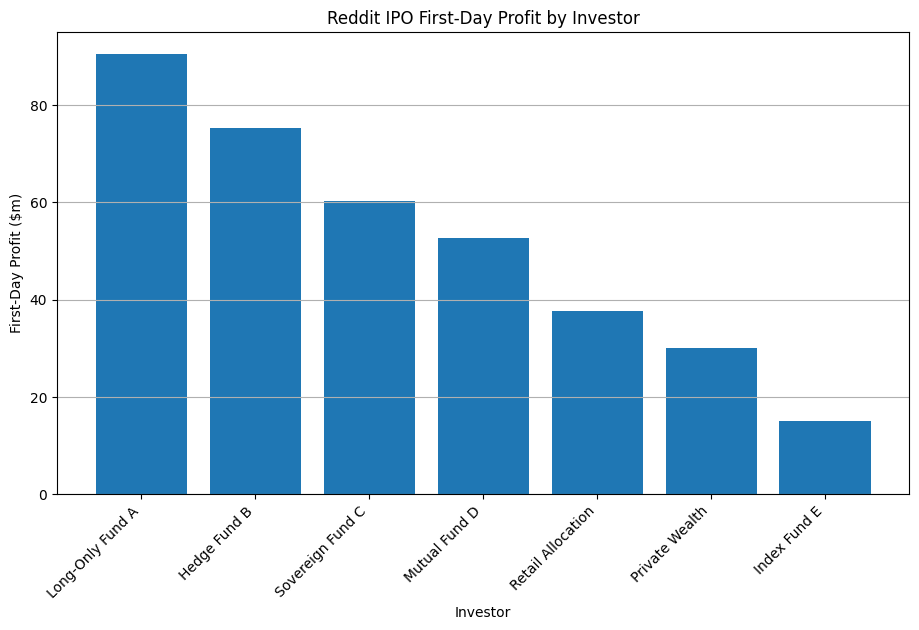

In [38]:
plt.figure(figsize=(11,6))

plt.bar(
    investor_book["Investor"],
    investor_book["First-Day Profit ($m)"]
)

plt.title("Reddit IPO First-Day Profit by Investor")
plt.xlabel("Investor")
plt.ylabel("First-Day Profit ($m)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

In [39]:
allocation_summary = pd.DataFrame({
    "Metric": [
        "Total Shares Requested",
        "Shares Offered",
        "Oversubscription Ratio",
        "Allocation Ratio",
        "IPO Offer Price",
        "First-Day Close",
        "First-Day Return"
    ],
    "Value": [
        f"{total_requested_shares:.1f} million",
        f"{shares_available:.1f} million",
        f"{total_requested_shares / shares_available:.2f}x",
        f"{allocation_ratio:.2%}",
        f"${ipo_price:.2f}",
        f"${first_day_close:.2f}",
        f"{ipo_pop:.2f}%"
    ]
})

allocation_summary

,Metric,Value
0,Total Shares Requested,48.0 million
1,Shares Offered,22.0 million
2,Oversubscription Ratio,2.18x
3,Allocation Ratio,45.83%
4,IPO Offer Price,$34.00
5,First-Day Close,$50.44
6,First-Day Return,48.35%


The IPO allocation simulation shows that Reddit’s IPO was meaningfully oversubscribed. Based on simulated demand of 48 million shares against 22 million shares offered, investors would receive only 45.8% of their requested allocation. The first-day price increase from $34.00 to $50.44 generated a 48.35% return for allocated investors, meaning allocation access was a key driver of IPO investor returns.

Did Reddit continue to outperform after IPO, or was most of the return captured only on day one?

In [40]:
tickers = ["RDDT", "META", "SNAP", "PINS", "GOOGL", "SPOT", "SPY"]

price_data = yf.download(
    tickers,
    start="2024-03-21",
    progress=False
)["Close"]

price_data.head()

/tmp/ipykernel_1618/892519485.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(


Ticker,GOOGL,META,PINS,RDDT,SNAP,SPOT,SPY
Date,,,,,,,
2024-03-21,146.302719,504.340942,34.330002,50.439999,11.16,259.640015,509.793213
2024-03-22,149.444839,506.148651,33.889999,46.000000,11.40,264.950012,508.826691
2024-03-25,148.750977,499.632843,34.970001,59.799999,11.26,261.920013,507.420959
2024-03-26,149.345688,492.550873,35.509998,65.110001,11.31,262.809998,506.483734
2024-03-27,149.543945,490.534576,34.880001,57.750000,11.45,260.200012,510.740112


In [41]:
normalised_prices = price_data / price_data.iloc[0] * 100

normalised_prices.head()

Ticker,GOOGL,META,PINS,RDDT,SNAP,SPOT,SPY
Date,,,,,,,
2024-03-21,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2024-03-22,102.147684,100.358430,98.718315,91.197465,102.150536,102.045138,99.810409
2024-03-25,101.673419,99.066485,101.864257,118.556703,100.896061,100.878138,99.534664
2024-03-26,102.079913,97.662282,103.437217,129.084065,101.344091,101.220915,99.350819
2024-03-27,102.215424,97.262494,101.602095,114.492469,102.598566,100.215682,100.185742


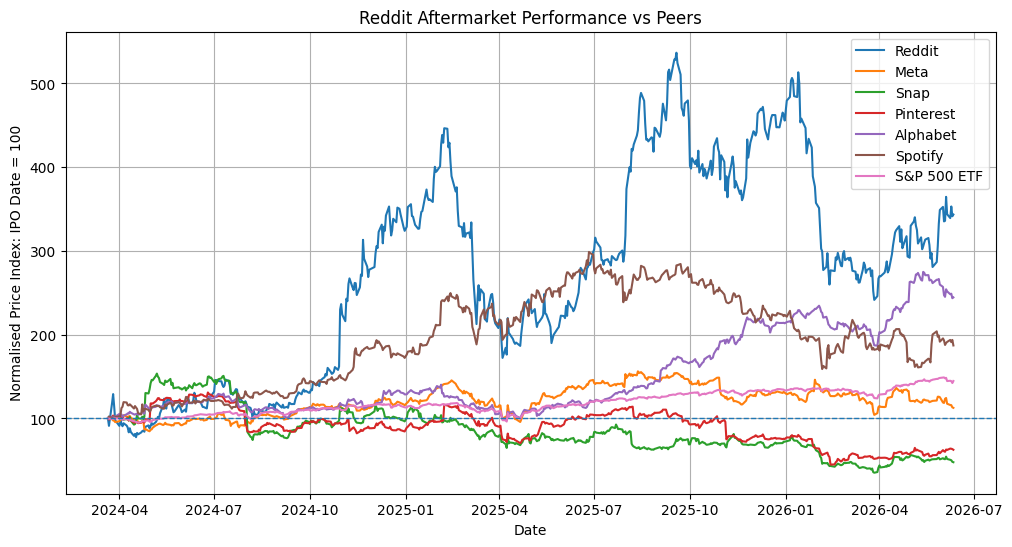

In [42]:
plt.figure(figsize=(12,6))

plt.plot(normalised_prices.index, normalised_prices["RDDT"], label="Reddit")
plt.plot(normalised_prices.index, normalised_prices["META"], label="Meta")
plt.plot(normalised_prices.index, normalised_prices["SNAP"], label="Snap")
plt.plot(normalised_prices.index, normalised_prices["PINS"], label="Pinterest")
plt.plot(normalised_prices.index, normalised_prices["GOOGL"], label="Alphabet")
plt.plot(normalised_prices.index, normalised_prices["SPOT"], label="Spotify")
plt.plot(normalised_prices.index, normalised_prices["SPY"], label="S&P 500 ETF")

plt.axhline(100, linestyle="--", linewidth=1)

plt.title("Reddit Aftermarket Performance vs Peers")
plt.xlabel("Date")
plt.ylabel("Normalised Price Index: IPO Date = 100")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
aftermarket_returns = (price_data.iloc[-1] / price_data.iloc[0] - 1) * 100

aftermarket_returns_df = aftermarket_returns.reset_index()
aftermarket_returns_df.columns = ["Ticker", "Return Since Reddit IPO Date (%)"]

aftermarket_returns_df.sort_values(
    by="Return Since Reddit IPO Date (%)",
    ascending=False
)

,Ticker,Return Since Reddit IPO Date (%)
3,RDDT,243.497223
0,GOOGL,144.540902
5,SPOT,87.182242
6,SPY,44.717503
1,META,12.707485
2,PINS,-37.372564
4,SNAP,-52.240143


In [44]:
reddit_return = aftermarket_returns["RDDT"]

peer_tickers = ["META", "SNAP", "PINS", "GOOGL", "SPOT"]
peer_median_return = aftermarket_returns[peer_tickers].median()

spy_return = aftermarket_returns["SPY"]

print(f"Reddit return since IPO date: {reddit_return:.2f}%")
print(f"Peer median return since Reddit IPO date: {peer_median_return:.2f}%")
print(f"SPY return since Reddit IPO date: {spy_return:.2f}%")

Reddit return since IPO date: 243.50%
Peer median return since Reddit IPO date: 12.71%
SPY return since Reddit IPO date: 44.72%


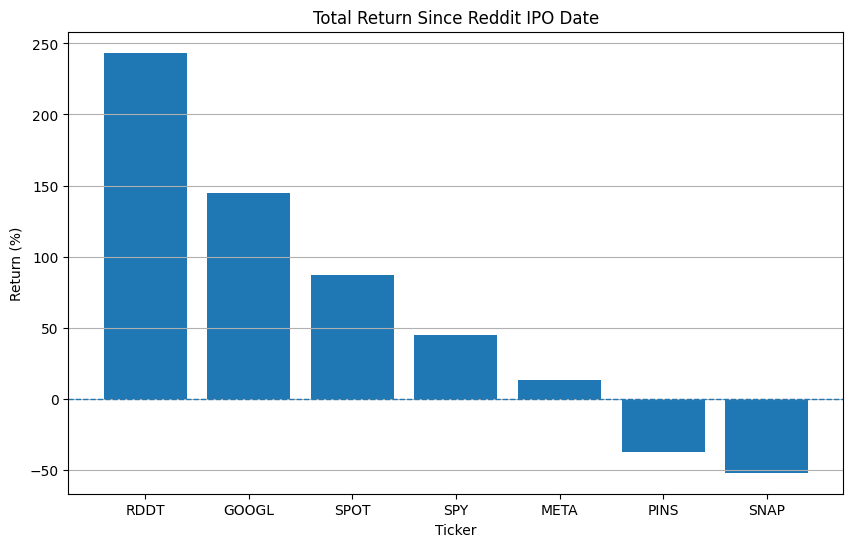

In [45]:
aftermarket_returns_df_sorted = aftermarket_returns_df.sort_values(
    by="Return Since Reddit IPO Date (%)",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    aftermarket_returns_df_sorted["Ticker"],
    aftermarket_returns_df_sorted["Return Since Reddit IPO Date (%)"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Total Return Since Reddit IPO Date")
plt.xlabel("Ticker")
plt.ylabel("Return (%)")
plt.grid(axis="y")

plt.show()

The aftermarket performance analysis compares Reddit’s post-IPO return against social media, digital advertising and platform peers. If Reddit outperforms both the peer median and SPY, this suggests the IPO was not only underpriced on day one but also supported by continued investor confidence. However, if Reddit’s return is mainly concentrated in the first-day pop, the IPO upside was largely captured by allocated IPO investors rather than later public-market buyers.

Risk Analysis — Volatility, Drawdown and Sharpe Ratio

In [46]:
daily_returns = price_data.pct_change().dropna()

daily_returns.head()

Ticker,GOOGL,META,PINS,RDDT,SNAP,SPOT,SPY
Date,,,,,,,
2024-03-22,0.021477,0.003584,-0.012817,-0.088025,0.021505,0.020451,-0.001896
2024-03-25,-0.004643,-0.012873,0.031868,0.300000,-0.012281,-0.011436,-0.002763
2024-03-26,0.003998,-0.014174,0.015442,0.088796,0.004441,0.003398,-0.001847
2024-03-27,0.001328,-0.004094,-0.017741,-0.113039,0.012378,-0.009931,0.008404
2024-03-28,0.000398,-0.016766,-0.006021,-0.145974,0.002620,0.014220,-0.000191


In [47]:
annualised_volatility = daily_returns.std() * np.sqrt(252) * 100

volatility_df = annualised_volatility.reset_index()
volatility_df.columns = ["Ticker", "Annualised Volatility (%)"]

volatility_df.sort_values(
    by="Annualised Volatility (%)",
    ascending=False
)

,Ticker,Annualised Volatility (%)
3,RDDT,81.129810
4,SNAP,60.767440
2,PINS,49.863267
5,SPOT,44.761775
1,META,36.108173
0,GOOGL,30.472085
6,SPY,16.352056


In [48]:
cumulative_returns = (1 + daily_returns).cumprod()

running_max = cumulative_returns.cummax()

drawdowns = cumulative_returns / running_max - 1

max_drawdown = drawdowns.min() * 100

drawdown_df = max_drawdown.reset_index()
drawdown_df.columns = ["Ticker", "Maximum Drawdown (%)"]

drawdown_df.sort_values(
    by="Maximum Drawdown (%)"
)

,Ticker,Maximum Drawdown (%)
4,SNAP,-77.071177
2,PINS,-65.718096
3,RDDT,-61.412776
5,SPOT,-46.803713
1,META,-34.150815
0,GOOGL,-29.805875
6,SPY,-18.755239


In [49]:
risk_free_rate = 0.045

annualised_return = daily_returns.mean() * 252
annualised_vol = daily_returns.std() * np.sqrt(252)

sharpe_ratio = (annualised_return - risk_free_rate) / annualised_vol

sharpe_df = sharpe_ratio.reset_index()
sharpe_df.columns = ["Ticker", "Sharpe Ratio"]

sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

,Ticker,Sharpe Ratio
0,GOOGL,1.331805
3,RDDT,1.022788
6,SPY,0.828864
5,SPOT,0.755002
1,META,0.205148
2,PINS,-0.262778
4,SNAP,-0.319825


In [50]:
risk_summary = aftermarket_returns_df.merge(
    volatility_df,
    on="Ticker",
    how="left"
).merge(
    drawdown_df,
    on="Ticker",
    how="left"
).merge(
    sharpe_df,
    on="Ticker",
    how="left"
)

risk_summary = risk_summary.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

risk_summary

,Ticker,Return Since Reddit IPO Date (%),Annualised Volatility (%),Maximum Drawdown (%),Sharpe Ratio
0,GOOGL,144.540902,30.472085,-29.805875,1.331805
3,RDDT,243.497223,81.129810,-61.412776,1.022788
6,SPY,44.717503,16.352056,-18.755239,0.828864
5,SPOT,87.182242,44.761775,-46.803713,0.755002
1,META,12.707485,36.108173,-34.150815,0.205148
2,PINS,-37.372564,49.863267,-65.718096,-0.262778
4,SNAP,-52.240143,60.767440,-77.071177,-0.319825


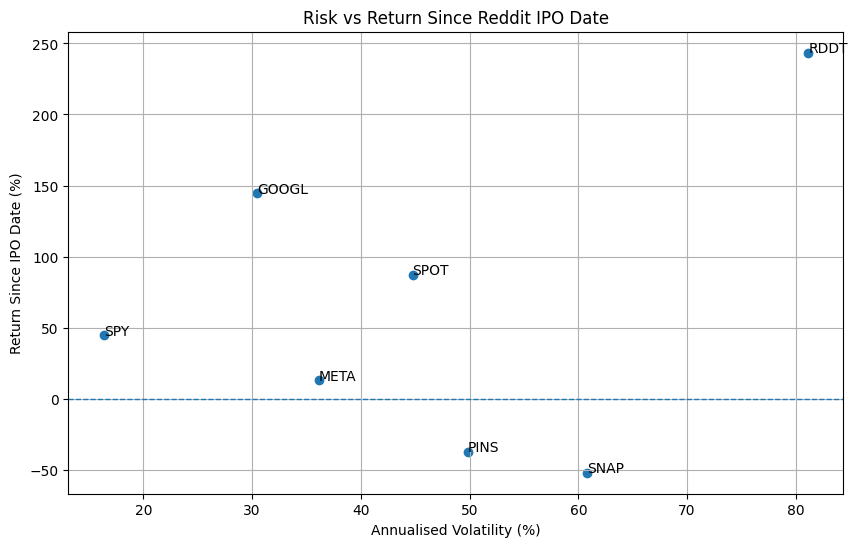

In [51]:
plt.figure(figsize=(10,6))

plt.scatter(
    risk_summary["Annualised Volatility (%)"],
    risk_summary["Return Since Reddit IPO Date (%)"]
)

for i, row in risk_summary.iterrows():
    plt.text(
        row["Annualised Volatility (%)"],
        row["Return Since Reddit IPO Date (%)"],
        row["Ticker"]
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Risk vs Return Since Reddit IPO Date")
plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Return Since IPO Date (%)")
plt.grid(True)

plt.show()

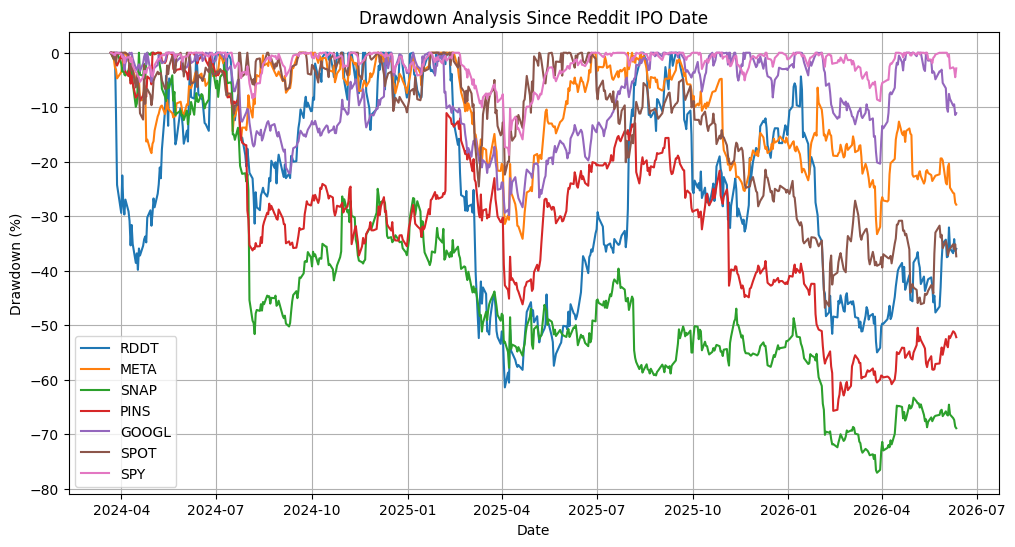

In [52]:
plt.figure(figsize=(12,6))

for ticker in ["RDDT", "META", "SNAP", "PINS", "GOOGL", "SPOT", "SPY"]:
    plt.plot(drawdowns.index, drawdowns[ticker] * 100, label=ticker)

plt.title("Drawdown Analysis Since Reddit IPO Date")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)

plt.show()

The risk analysis shows whether Reddit’s post-IPO performance was supported by efficient risk-adjusted returns. Annualised volatility measures how unstable the stock was after listing, maximum drawdown captures the largest investor loss from peak to trough, and the Sharpe ratio evaluates return earned per unit of risk. If Reddit shows high returns but also high volatility and drawdown, the IPO was attractive but remained a high-risk growth investment.

In [53]:
final_scorecard = pd.DataFrame({
    "Area": [
        "IPO Pricing",
        "First-Day Performance",
        "Money Left on Table",
        "Peer Valuation",
        "Bookbuilding Demand",
        "Investor Allocation",
        "Aftermarket Performance",
        "Risk Analysis"
    ],
    "Finding": [
        "IPO priced at $34, top of marketed range",
        f"First-day return was {ipo_pop:.2f}%",
        f"Approx. ${money_left_on_table_m:.2f}m left on table",
        "Valuation should be assessed against social media and digital advertising peers",
        f"Simulated oversubscription was {total_requested_shares / shares_available:.2f}x",
        f"Investors received approx. {allocation_ratio:.2%} of requested shares",
        "Post-IPO return should be compared against peer median and SPY",
        "High return potential but with large drawdowns and volatility"
    ],
    "ECM Interpretation": [
        "Strong pricing confidence from underwriters",
        "Indicates meaningful IPO underpricing",
        "Issuer may have sacrificed proceeds for strong aftermarket trading",
        "IPO price depends on growth, monetisation and profitability assumptions",
        "Strong demand supported pricing at the top of the range",
        "Allocation access created large investor advantage",
        "Shows whether IPO success continued beyond day-one pop",
        "Reddit remained a high-risk growth investment"
    ],
    "Signal": [
        "Positive",
        "Positive for IPO investors",
        "Negative for issuer proceeds",
        "Mixed",
        "Positive",
        "Positive for allocated investors",
        "Depends on actual return output",
        "Caution"
    ]
})

final_scorecard

,Area,Finding,ECM Interpretation,Signal
0,IPO Pricing,"IPO priced at $34, top of marketed range",Strong pricing confidence from underwriters,Positive
1,First-Day Performance,First-day return was 48.35%,Indicates meaningful IPO underpricing,Positive for IPO investors
2,Money Left on Table,Approx. $361.68m left on table,Issuer may have sacrificed proceeds for strong...,Negative for issuer proceeds
3,Peer Valuation,Valuation should be assessed against social me...,"IPO price depends on growth, monetisation and ...",Mixed
4,Bookbuilding Demand,Simulated oversubscription was 2.18x,Strong demand supported pricing at the top of ...,Positive
5,Investor Allocation,Investors received approx. 45.83% of requested...,Allocation access created large investor advan...,Positive for allocated investors
6,Aftermarket Performance,Post-IPO return should be compared against pee...,Shows whether IPO success continued beyond day...,Depends on actual return output
7,Risk Analysis,High return potential but with large drawdowns...,Reddit remained a high-risk growth investment,Caution


In [54]:
final_rating = pd.DataFrame({
    "Perspective": [
        "Issuer: Reddit",
        "Underwriters / ECM Bankers",
        "IPO Allocation Investors",
        "First-Day Public Buyers",
        "Long-Term Growth Investors"
    ],
    "Rating": [
        "Successful but underpriced",
        "Strong execution",
        "Highly attractive",
        "Cautious",
        "Conditional on growth and margin expansion"
    ],
    "Reason": [
        "Raised capital and created strong demand, but left money on the table",
        "Priced at top of range and supported positive aftermarket performance",
        "Received shares at $34 before strong first-day pop",
        "Bought after IPO discount had already disappeared",
        "Need confidence in revenue growth, ads, AI data licensing and profitability"
    ]
})

final_rating

,Perspective,Rating,Reason
0,Issuer: Reddit,Successful but underpriced,"Raised capital and created strong demand, but ..."
1,Underwriters / ECM Bankers,Strong execution,Priced at top of range and supported positive ...
2,IPO Allocation Investors,Highly attractive,Received shares at $34 before strong first-day...
3,First-Day Public Buyers,Cautious,Bought after IPO discount had already disappeared
4,Long-Term Growth Investors,Conditional on growth and margin expansion,"Need confidence in revenue growth, ads, AI dat..."


Reddit’s IPO was successful from an ECM execution perspective because the deal priced at the top of the range, generated strong investor demand, and produced a significant first-day return. The 48.35% IPO pop indicates that the offer was meaningfully underpriced, creating strong gains for allocated IPO investors.

However, from Reddit’s perspective as the issuer, the IPO also left substantial money on the table. Based on 22 million shares sold, the company could have raised approximately $362 million more if the offer had been priced closer to the first-day closing price. This reflects the classic ECM trade-off between maximising proceeds and ensuring positive aftermarket performance.

For investors, the conclusion is split. Investors who received IPO allocation at $34 benefited from a highly attractive entry point. In contrast, investors who bought after the first-day pop faced a much higher valuation and greater downside risk. The drawdown analysis shows Reddit behaved like a volatile high-growth stock rather than a stable mature platform.

Overall, Reddit’s IPO should be rated as a strong ECM transaction, attractive for allocated IPO investors, but higher risk for public-market buyers after listing.